In [1]:
# ============================================================
# NOTEBOOK 03
# CONFORMER AND CONFIGURATION GENERATION
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = {
    "rdkit": "rdkit",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:
        print(f"Installing missing package: {package_name}")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])

    else:
        print(f"{module_name}: already available")

print("\nEnvironment check complete.")

Installing missing package: rdkit
numpy: already available
pandas: already available
matplotlib: already available

Environment check complete.


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
CONFIG_DIR = PROJECT_DIR / "configs"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [
    RAW_DIR,
    PROCESSED_DIR,
    CONFIG_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nConfiguration directory:")
print(CONFIG_DIR)

Project directory:
/content/drive/MyDrive/MLIP project

Configuration directory:
/content/drive/MyDrive/MLIP project/configs


In [4]:
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolAlign
from rdkit.Chem import rdMolDescriptors

In [5]:
GLOBAL_SEED = 12345

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("Global random seed:", GLOBAL_SEED)

Global random seed: 12345


In [6]:
MOLECULE_TABLE = RAW_DIR / "pilot_molecules_24.csv"

if not MOLECULE_TABLE.exists():
    raise FileNotFoundError(
        f"Required file not found:\n{MOLECULE_TABLE}\n\n"
        "Run Notebook 02 first."
    )

molecule_df = pd.read_csv(MOLECULE_TABLE)

print("Loaded:", MOLECULE_TABLE)
print("Number of molecules:", len(molecule_df))

display(
    molecule_df[
        ["id", "name", "family", "canonical_smiles"]
    ]
)

Loaded: /content/drive/MyDrive/MLIP project/data/raw/pilot_molecules_24.csv
Number of molecules: 24


,id,name,family,canonical_smiles
0,M01,benzene,aromatic_hydrocarbon,c1ccccc1
1,M02,toluene,aromatic_hydrocarbon,Cc1ccccc1
2,M03,naphthalene,aromatic_hydrocarbon,c1ccc2ccccc2c1
3,M04,anthracene,aromatic_hydrocarbon,c1ccc2cc3ccccc3cc2c1
4,M05,phenol,O_N_aromatic,Oc1ccccc1
5,M06,anisole,O_N_aromatic,COc1ccccc1
6,M07,pyridine,O_N_aromatic,c1ccncc1
7,M08,aniline,O_N_aromatic,Nc1ccccc1
8,M09,1_2_3_thiadiazole,S_heteroaromatic,c1csnn1
9,M10,BDT,S_heteroaromatic,c1cc2cc3sccc3cc2s1


In [7]:
assert len(molecule_df) == 24, (
    f"Expected 24 molecules, found {len(molecule_df)}"
)

assert molecule_df["id"].nunique() == 24, (
    "Molecule IDs are not unique."
)

assert molecule_df["canonical_smiles"].nunique() == 24, (
    "Canonical SMILES are not unique."
)

assert molecule_df["family"].nunique() == 6, (
    "Expected 6 chemical families."
)

print("Input validation passed.")

Input validation passed.


In [8]:
# ============================================================
# CONFORMER / CONFIGURATION PARAMETERS
# ============================================================

# Maximum number of MMFF-optimized starting conformers
MAX_BASE_CONFORMERS = 8

# RMSD pruning threshold during ETKDG embedding
# Heavy atoms are used for pruning.
EMBED_PRUNE_RMS = 0.50

# Maximum number of final candidate configurations per molecule
TARGET_CONFIGS_PER_MOLECULE = 24

# Random perturbation amplitudes in Angstrom
PERTURBATION_SIGMAS = [
    0.025,
    0.050,
    0.075,
    0.100,
    0.125,
]

# Maximum allowed displacement of any atom from its
# corresponding parent conformer.
MAX_ATOM_DISPLACEMENT = 0.50

# Minimum RMSD between accepted configurations.
# This is used after optimal alignment.
MIN_CONFIG_RMSD = 0.05

# Bond-length ratio limits relative to the parent geometry.
MIN_BOND_RATIO = 0.75
MAX_BOND_RATIO = 1.30

# Minimum nonbonded atom-atom separation relative to
# sum of van der Waals radii.
MIN_NONBONDED_VDW_RATIO = 0.65

# MMFF optimization
MMFF_MAX_ITERS = 1000

# Number of attempts to generate a configuration
# before giving up on a molecule.
MAX_GENERATION_ATTEMPTS = 5000

print("Configuration parameters loaded.")

Configuration parameters loaded.


In [9]:
COVALENT_RADII = {
    "H": 0.31,
    "C": 0.76,
    "N": 0.71,
    "O": 0.66,
    "F": 0.57,
    "S": 1.05,
}

VDW_RADII = {
    "H": 1.20,
    "C": 1.70,
    "N": 1.55,
    "O": 1.52,
    "F": 1.47,
    "S": 1.80,
}

SUPPORTED_ELEMENTS = set(COVALENT_RADII)

print("Supported elements:", sorted(SUPPORTED_ELEMENTS))

Supported elements: ['C', 'F', 'H', 'N', 'O', 'S']


In [10]:
def get_coordinates(mol, conf_id=0):
    """
    Return Cartesian coordinates as an (N, 3) numpy array.
    Units: Angstrom.
    """
    conf = mol.GetConformer(conf_id)

    coords = np.array(
        [
            [
                conf.GetAtomPosition(i).x,
                conf.GetAtomPosition(i).y,
                conf.GetAtomPosition(i).z,
            ]
            for i in range(mol.GetNumAtoms())
        ],
        dtype=float,
    )

    return coords

In [11]:
def set_coordinates(mol, coords, conf_id=0):
    """
    Replace coordinates of an existing conformer.
    """

    conf = mol.GetConformer(conf_id)

    for i, xyz in enumerate(coords):
        conf.SetAtomPosition(
            i,
            xyz.tolist()
        )

    return mol

In [12]:
def center_coordinates(coords):
    """
    Remove the simple geometric center translation.
    """
    coords = np.asarray(coords, dtype=float)

    center = coords.mean(axis=0)

    return coords - center

In [13]:
def aligned_rmsd(mol, coords_a, coords_b):
    """
    Calculate heavy-atom RMSD after optimal rotational/translation alignment.

    This uses a temporary molecule containing coords_a and coords_b.
    """

    mol_temp = Chem.Mol(mol)

    mol_temp.RemoveAllConformers()

    conf_a = Chem.Conformer(mol_temp.GetNumAtoms())
    conf_b = Chem.Conformer(mol_temp.GetNumAtoms())

    for i in range(mol_temp.GetNumAtoms()):

        conf_a.SetAtomPosition(
            i,
            coords_a[i].tolist()
        )

        conf_b.SetAtomPosition(
            i,
            coords_b[i].tolist()
        )

    mol_temp.AddConformer(conf_a, assignId=True)
    mol_temp.AddConformer(conf_b, assignId=True)

    heavy_atom_indices = [
        atom.GetIdx()
        for atom in mol_temp.GetAtoms()
        if atom.GetAtomicNum() > 1
    ]

    return rdMolAlign.GetBestRMS(
        mol_temp,
        mol_temp,
        prbId=1,
        refId=0,
        atomIds=[
            (i, i)
            for i in heavy_atom_indices
        ],
    )

In [28]:
# ============================================================
# CELL 13 — Robust RMSD calculation
# ============================================================

def aligned_rmsd(mol, coords_a, coords_b):
    """
    Calculate heavy-atom RMSD after optimal alignment.

    Parameters
    ----------
    mol : RDKit molecule
        Molecule whose atom ordering is shared by both coordinate sets.

    coords_a : numpy.ndarray
        First coordinate array, shape (N, 3), in Angstrom.

    coords_b : numpy.ndarray
        Second coordinate array, shape (N, 3), in Angstrom.

    Returns
    -------
    float
        Best heavy-atom RMSD in Angstrom.

    Notes
    -----
    Hydrogen atoms are excluded from the RMSD calculation.
    The atom ordering is identical because both coordinate sets
    originate from the same RDKit molecule.
    """

    coords_a = np.asarray(coords_a, dtype=float)
    coords_b = np.asarray(coords_b, dtype=float)

    if coords_a.shape != coords_b.shape:
        raise ValueError(
            "Coordinate arrays have different shapes: "
            f"{coords_a.shape} vs {coords_b.shape}"
        )

    if coords_a.shape[1] != 3:
        raise ValueError(
            "Coordinates must have shape (N, 3)."
        )

    # --------------------------------------------------------
    # Heavy-atom indices
    # --------------------------------------------------------

    heavy_indices = [
        atom.GetIdx()
        for atom in mol.GetAtoms()
        if atom.GetAtomicNum() > 1
    ]

    if len(heavy_indices) == 0:
        raise ValueError(
            "Molecule contains no heavy atoms."
        )

    A = coords_a[heavy_indices]
    B = coords_b[heavy_indices]

    # --------------------------------------------------------
    # Remove translation
    # --------------------------------------------------------

    A_center = A.mean(axis=0)
    B_center = B.mean(axis=0)

    A = A - A_center
    B = B - B_center

    # --------------------------------------------------------
    # Kabsch alignment
    # --------------------------------------------------------

    covariance = B.T @ A

    U, S, Vt = np.linalg.svd(
        covariance
    )

    determinant = np.linalg.det(
        U @ Vt
    )

    correction = np.eye(3)

    if determinant < 0:
        correction[-1, -1] = -1

    rotation = (
        U
        @ correction
        @ Vt
    )

    B_aligned = B @ rotation

    # --------------------------------------------------------
    # RMSD
    # --------------------------------------------------------

    squared_difference = (
        A - B_aligned
    ) ** 2

    rmsd = np.sqrt(
        np.mean(
            squared_difference
        )
    )

    return float(rmsd)

In [15]:
def geometry_quality_check(
    mol,
    coords,
    parent_coords,
    min_bond_ratio=MIN_BOND_RATIO,
    max_bond_ratio=MAX_BOND_RATIO,
    min_vdw_ratio=MIN_NONBONDED_VDW_RATIO,
    max_atom_displacement=MAX_ATOM_DISPLACEMENT,
):
    """
    Check whether a perturbed geometry is reasonable.

    Tests:
    1. All coordinates are finite.
    2. No atom moves excessively from its parent.
    3. Bond lengths remain within reasonable limits.
    4. Nonbonded atoms do not become unrealistically close.
    """

    coords = np.asarray(coords, dtype=float)
    parent_coords = np.asarray(parent_coords, dtype=float)

    # --------------------------------------------------------
    # Test 1: finite coordinates
    # --------------------------------------------------------

    if not np.all(np.isfinite(coords)):
        return False, "nonfinite_coordinates"

    # --------------------------------------------------------
    # Test 2: maximum displacement
    # --------------------------------------------------------

    displacements = np.linalg.norm(
        coords - parent_coords,
        axis=1
    )

    max_displacement = displacements.max()

    if max_displacement > max_atom_displacement:
        return False, "excessive_atom_displacement"

    # --------------------------------------------------------
    # Test 3: bonded distances
    # --------------------------------------------------------

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        current_distance = np.linalg.norm(
            coords[i] - coords[j]
        )

        parent_distance = np.linalg.norm(
            parent_coords[i] - parent_coords[j]
        )

        if parent_distance <= 0:
            return False, "invalid_parent_bond"

        ratio = current_distance / parent_distance

        if ratio < min_bond_ratio:
            return False, "bond_too_short"

        if ratio > max_bond_ratio:
            return False, "bond_too_long"

    # --------------------------------------------------------
    # Test 4: nonbonded contacts
    # --------------------------------------------------------

    atom_count = mol.GetNumAtoms()

    bonded_pairs = set()

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bonded_pairs.add((min(i, j), max(i, j)))

    for i in range(atom_count):

        symbol_i = mol.GetAtomWithIdx(i).GetSymbol()

        for j in range(i + 1, atom_count):

            if (i, j) in bonded_pairs:
                continue

            symbol_j = mol.GetAtomWithIdx(j).GetSymbol()

            distance = np.linalg.norm(
                coords[i] - coords[j]
            )

            vdw_sum = (
                VDW_RADII[symbol_i]
                +
                VDW_RADII[symbol_j]
            )

            minimum_allowed = min_vdw_ratio * vdw_sum

            if distance < minimum_allowed:
                return False, "nonbonded_clash"

    return True, "pass"

In [16]:
def perturb_coordinates(
    parent_coords,
    sigma,
    rng
):
    """
    Apply isotropic Gaussian Cartesian perturbations.

    The resulting structure is NOT MMFF optimized.
    """

    parent_coords = np.asarray(
        parent_coords,
        dtype=float
    )

    displacement = rng.normal(
        loc=0.0,
        scale=sigma,
        size=parent_coords.shape
    )

    perturbed = parent_coords + displacement

    # Remove overall translation.
    perturbed = center_coordinates(perturbed)

    # Center parent coordinates as well for consistency.
    centered_parent = center_coordinates(parent_coords)

    # Restore the parent geometric center.
    parent_center = parent_coords.mean(axis=0)

    perturbed += parent_center

    return perturbed

In [17]:
def generate_base_conformers(
    smiles,
    max_conformers=MAX_BASE_CONFORMERS,
    seed=GLOBAL_SEED,
):
    """
    Generate and MMFF-optimize a set of base conformers.

    Returns:
        molecule with conformers
        list of conformer IDs
        MMFF energies
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    mol = Chem.AddHs(mol)

    # --------------------------------------------------------
    # ETKDGv3
    # --------------------------------------------------------

    params = AllChem.ETKDGv3()

    params.randomSeed = int(seed)
    params.pruneRmsThresh = EMBED_PRUNE_RMS
    params.onlyHeavyAtomsForRMS = True
    params.enforceChirality = True
    params.useRandomCoords = False
    params.numThreads = 0

    conformer_ids = AllChem.EmbedMultipleConfs(
        mol,
        numConfs=max_conformers,
        params=params,
    )

    conformer_ids = list(conformer_ids)

    if len(conformer_ids) == 0:

        # Second attempt using random coordinates.
        params.randomSeed = int(seed + 1000)
        params.useRandomCoords = True

        conformer_ids = AllChem.EmbedMultipleConfs(
            mol,
            numConfs=max_conformers,
            params=params,
        )

        conformer_ids = list(conformer_ids)

    if len(conformer_ids) == 0:
        raise RuntimeError(
            "Could not generate a 3D conformer."
        )

    # --------------------------------------------------------
    # MMFF optimization
    # --------------------------------------------------------

    mmff_results = AllChem.MMFFOptimizeMoleculeConfs(
        mol,
        numThreads=0,
        maxIters=MMFF_MAX_ITERS,
    )

    energies = []

    for result in mmff_results:

        converged = result[0]
        energy = result[1]

        energies.append({
            "converged": int(converged == 0),
            "energy_kcal_mol": float(energy),
        })

    return mol, conformer_ids, energies

In [18]:
test_smiles = molecule_df.loc[
    molecule_df["id"] == "M01",
    "canonical_smiles"
].iloc[0]

test_mol, test_conf_ids, test_energies = generate_base_conformers(
    test_smiles
)

print("Generated conformers:", len(test_conf_ids))
print("MMFF results:")

for item in test_energies:
    print(item)

Generated conformers: 1
MMFF results:
{'converged': 1, 'energy_kcal_mol': 16.226966799891642}


In [19]:
base_conformer_data = {}

base_summary = []

for _, row in molecule_df.iterrows():

    molecule_id = row["id"]
    name = row["name"]
    smiles = row["canonical_smiles"]

    print(
        f"Generating conformers for "
        f"{molecule_id} — {name}"
    )

    mol, conf_ids, energies = generate_base_conformers(
        smiles=smiles,
        max_conformers=MAX_BASE_CONFORMERS,
        seed=GLOBAL_SEED + int(
            molecule_id[1:]
        ),
    )

    base_conformer_data[molecule_id] = {
        "mol": mol,
        "conf_ids": conf_ids,
        "energies": energies,
    }

    base_summary.append({
        "id": molecule_id,
        "name": name,
        "number_base_conformers": len(conf_ids),
        "number_mmff_results": len(energies),
    })

base_summary_df = pd.DataFrame(base_summary)

display(base_summary_df)

Generating conformers for M01 — benzene
Generating conformers for M02 — toluene
Generating conformers for M03 — naphthalene
Generating conformers for M04 — anthracene
Generating conformers for M05 — phenol
Generating conformers for M06 — anisole
Generating conformers for M07 — pyridine
Generating conformers for M08 — aniline
Generating conformers for M09 — 1_2_3_thiadiazole
Generating conformers for M10 — BDT
Generating conformers for M11 — benzobithiophene
Generating conformers for M12 — terthiophene
Generating conformers for M13 — 4_nitroaniline
Generating conformers for M14 — 4_dimethylaminobenzonitrile
Generating conformers for M15 — 4_nitrostyrene
Generating conformers for M16 — 2_4_nitrophenyl_thiophene
Generating conformers for M17 — fluorobenzene
Generating conformers for M18 — 1_4_difluorobenzene
Generating conformers for M19 — 2_fluorothiophene
Generating conformers for M20 — 2_3_5_6_tetrafluoropyridine
Generating conformers for M21 — benzoquinone
Generating conformers for M2

,id,name,number_base_conformers,number_mmff_results
0,M01,benzene,1,1
1,M02,toluene,1,1
2,M03,naphthalene,1,1
3,M04,anthracene,1,1
4,M05,phenol,1,1
5,M06,anisole,1,1
6,M07,pyridine,1,1
7,M08,aniline,1,1
8,M09,1_2_3_thiadiazole,1,1
9,M10,BDT,1,1


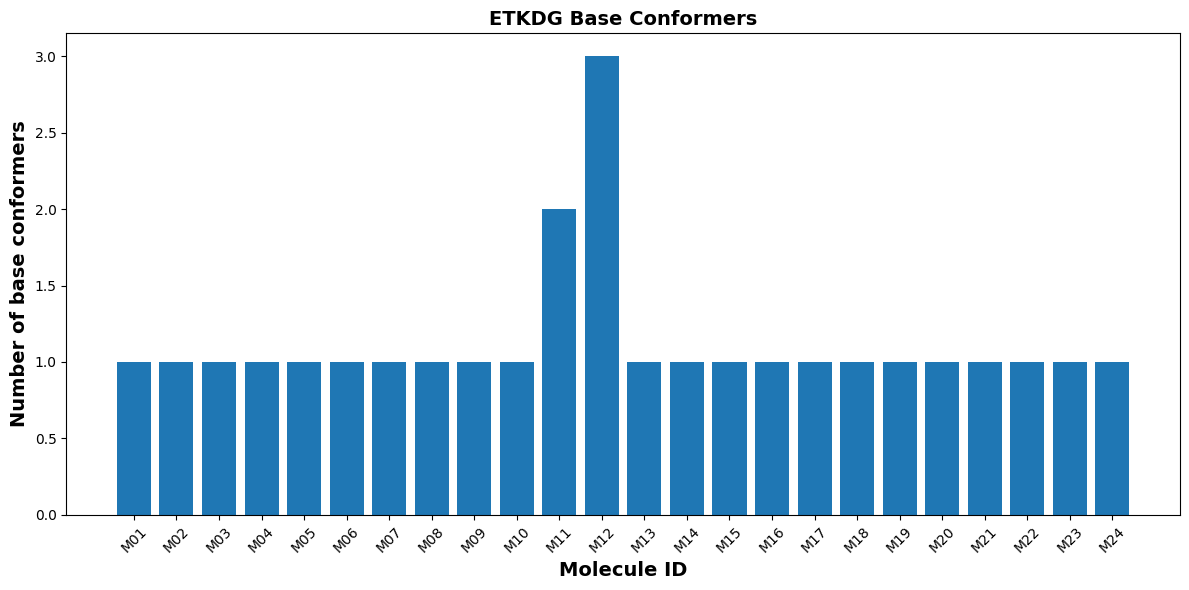

Saved: /content/drive/MyDrive/MLIP project/results/figures/base_conformer_counts.png


In [20]:
plt.figure(figsize=(12, 6))

plt.bar(
    base_summary_df["id"],
    base_summary_df["number_base_conformers"]
)

plt.xlabel(
    "Molecule ID",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of base conformers",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "ETKDG Base Conformers",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.tight_layout()

path = FIGURES_DIR / "base_conformer_counts.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [21]:
def write_xyz(
    path,
    symbols,
    coords,
    comment=""
):
    """
    Write one configuration as XYZ.
    """

    path = Path(path)

    with open(path, "w") as f:

        f.write(f"{len(symbols)}\n")
        f.write(f"{comment}\n")

        for symbol, xyz in zip(symbols, coords):

            f.write(
                f"{symbol:2s} "
                f"{xyz[0]: .8f} "
                f"{xyz[1]: .8f} "
                f"{xyz[2]: .8f}\n"
            )

In [22]:
def get_atom_symbols(mol):

    return [
        atom.GetSymbol()
        for atom in mol.GetAtoms()
    ]

In [23]:
def make_configuration_record(
    molecule_id,
    molecule_name,
    family,
    configuration_id,
    source_type,
    parent_conformer,
    coords,
    parent_coords,
    perturbation_sigma,
):
    """
    Create metadata for one candidate configuration.
    """

    displacement = np.linalg.norm(
        coords - parent_coords,
        axis=1
    )

    rmsd = aligned_rmsd(
        mol=current_mol_for_rmsd,
        coords_a=parent_coords,
        coords_b=coords,
    )

    return {
        "molecule_id": molecule_id,
        "molecule_name": molecule_name,
        "family": family,
        "configuration_id": configuration_id,
        "source_type": source_type,
        "parent_conformer": parent_conformer,
        "perturbation_sigma_A": perturbation_sigma,
        "rmsd_from_parent_A": rmsd,
        "max_atom_displacement_A": float(
            displacement.max()
        ),
        "mean_atom_displacement_A": float(
            displacement.mean()
        ),
    }

In [24]:
def make_configuration_record(
    mol,
    molecule_id,
    molecule_name,
    family,
    configuration_id,
    source_type,
    parent_conformer,
    coords,
    parent_coords,
    perturbation_sigma,
):
    """
    Create metadata for one candidate configuration.
    """

    displacement = np.linalg.norm(
        coords - parent_coords,
        axis=1
    )

    rmsd = aligned_rmsd(
        mol=mol,
        coords_a=parent_coords,
        coords_b=coords,
    )

    return {
        "molecule_id": molecule_id,
        "molecule_name": molecule_name,
        "family": family,
        "configuration_id": configuration_id,
        "source_type": source_type,
        "parent_conformer": parent_conformer,
        "perturbation_sigma_A": perturbation_sigma,
        "rmsd_from_parent_A": rmsd,
        "max_atom_displacement_A": float(
            displacement.max()
        ),
        "mean_atom_displacement_A": float(
            displacement.mean()
        ),
    }

In [25]:
def generate_candidate_configurations(
    mol,
    molecule_id,
    molecule_name,
    family,
    target_count=TARGET_CONFIGS_PER_MOLECULE,
    seed=GLOBAL_SEED,
):
    """
    Generate DFT-ready candidate configurations.

    Strategy:
        1. Keep all retained MMFF-optimized base conformers.
        2. Add controlled Cartesian perturbations.
        3. Reject unreasonable geometries.
        4. Reject near-duplicate configurations.
        5. Stop at target_count.

    IMPORTANT:
        Perturbed structures are NOT re-optimized.
    """

    rng = np.random.default_rng(seed)

    conformer_ids = list(
        range(mol.GetNumConformers())
    )

    if len(conformer_ids) == 0:
        raise RuntimeError(
            f"No conformers available for {molecule_id}"
        )

    candidates = []

    # --------------------------------------------------------
    # STEP 1
    # Add base conformers
    # --------------------------------------------------------

    for conf_id in conformer_ids:

        coords = get_coordinates(
            mol,
            conf_id=conf_id
        )

        candidates.append({
            "coords": coords.copy(),
            "source_type": "mmff_conformer",
            "parent_conformer": conf_id,
            "sigma": 0.0,
        })

    # --------------------------------------------------------
    # STEP 2
    # Generate perturbations
    # --------------------------------------------------------

    attempts = 0

    while (
        len(candidates) < target_count
        and
        attempts < MAX_GENERATION_ATTEMPTS
    ):

        attempts += 1

        # Cycle through parent conformers
        parent_index = (
            attempts - 1
        ) % len(conformer_ids)

        parent_conf_id = conformer_ids[
            parent_index
        ]

        parent_coords = get_coordinates(
            mol,
            conf_id=parent_conf_id
        )

        # Cycle through perturbation strengths
        sigma = PERTURBATION_SIGMAS[
            (attempts - 1)
            %
            len(PERTURBATION_SIGMAS)
        ]

        candidate_coords = perturb_coordinates(
            parent_coords,
            sigma=sigma,
            rng=rng,
        )

        # ----------------------------------------------------
        # Geometry filtering
        # ----------------------------------------------------

        passed, reason = geometry_quality_check(
            mol=mol,
            coords=candidate_coords,
            parent_coords=parent_coords,
        )

        if not passed:
            continue

        # ----------------------------------------------------
        # Duplicate / similarity filtering
        # ----------------------------------------------------

        too_similar = False

        for existing in candidates:

            rmsd = aligned_rmsd(
                mol,
                existing["coords"],
                candidate_coords,
            )

            if rmsd < MIN_CONFIG_RMSD:

                too_similar = True
                break

        if too_similar:
            continue

        # ----------------------------------------------------
        # Accept configuration
        # ----------------------------------------------------

        candidates.append({
            "coords": candidate_coords.copy(),
            "source_type": "perturbed",
            "parent_conformer": parent_conf_id,
            "sigma": sigma,
        })

    return candidates, attempts

In [29]:
all_configuration_records = []
generation_statistics = []

for _, row in molecule_df.iterrows():

    molecule_id = row["id"]
    molecule_name = row["name"]
    family = row["family"]

    print(
        "\n"
        + "=" * 60
    )

    print(
        f"{molecule_id} — {molecule_name}"
    )

    data = base_conformer_data[molecule_id]

    mol = data["mol"]

    candidates, attempts = generate_candidate_configurations(
        mol=mol,
        molecule_id=molecule_id,
        molecule_name=molecule_name,
        family=family,
        target_count=TARGET_CONFIGS_PER_MOLECULE,
        seed=GLOBAL_SEED + int(
            molecule_id[1:]
        ),
    )

    print(
        f"Accepted configurations: "
        f"{len(candidates)}"
    )

    print(
        f"Generation attempts: "
        f"{attempts}"
    )

    # --------------------------------------------------------
    # Molecule-specific output directory
    # --------------------------------------------------------

    molecule_dir = (
        CONFIG_DIR /
        f"{molecule_id}_{molecule_name}"
    )

    molecule_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    symbols = get_atom_symbols(mol)

    accepted_count = 0

    for index, candidate in enumerate(
        candidates,
        start=1
    ):

        configuration_id = (
            f"{molecule_id}_C{index:03d}"
        )

        coords = candidate["coords"]

        parent_conf_id = candidate[
            "parent_conformer"
        ]

        parent_coords = get_coordinates(
            mol,
            conf_id=parent_conf_id
        )

        # ----------------------------------------------------
        # Calculate final metadata
        # ----------------------------------------------------

        rmsd = aligned_rmsd(
            mol,
            parent_coords,
            coords
        )

        displacement = np.linalg.norm(
            coords - parent_coords,
            axis=1
        )

        # ----------------------------------------------------
        # XYZ output
        # ----------------------------------------------------

        xyz_path = (
            molecule_dir /
            f"{configuration_id}.xyz"
        )

        write_xyz(
            path=xyz_path,
            symbols=symbols,
            coords=coords,
            comment=(
                f"{configuration_id} "
                f"{molecule_name} "
                f"family={family} "
                f"source={candidate['source_type']}"
            )
        )

        # ----------------------------------------------------
        # Manifest record
        # ----------------------------------------------------

        all_configuration_records.append({

            "molecule_id": molecule_id,

            "molecule_name": molecule_name,

            "family": family,

            "configuration_id": configuration_id,

            "xyz_path": str(
                xyz_path
            ),

            "source_type": candidate[
                "source_type"
            ],

            "parent_conformer": parent_conf_id,

            "perturbation_sigma_A": candidate[
                "sigma"
            ],

            "rmsd_from_parent_A": rmsd,

            "max_atom_displacement_A": float(
                displacement.max()
            ),

            "mean_atom_displacement_A": float(
                displacement.mean()
            ),

            "n_atoms": mol.GetNumAtoms(),

            "n_heavy_atoms": mol.GetNumHeavyAtoms(),
        })

        accepted_count += 1

    generation_statistics.append({

        "molecule_id": molecule_id,

        "molecule_name": molecule_name,

        "family": family,

        "base_conformers": len(
            data["conf_ids"]
        ),

        "candidate_configurations": accepted_count,

        "generation_attempts": attempts,

    })


M01 — benzene
Accepted configurations: 24
Generation attempts: 88

M02 — toluene
Accepted configurations: 24
Generation attempts: 94

M03 — naphthalene
Accepted configurations: 24
Generation attempts: 97

M04 — anthracene
Accepted configurations: 24
Generation attempts: 114

M05 — phenol
Accepted configurations: 24
Generation attempts: 119

M06 — anisole
Accepted configurations: 24
Generation attempts: 93

M07 — pyridine
Accepted configurations: 24
Generation attempts: 108

M08 — aniline
Accepted configurations: 24
Generation attempts: 113

M09 — 1_2_3_thiadiazole
Accepted configurations: 24
Generation attempts: 73

M10 — BDT
Accepted configurations: 24
Generation attempts: 114

M11 — benzobithiophene
Accepted configurations: 24
Generation attempts: 113

M12 — terthiophene
Accepted configurations: 24
Generation attempts: 143

M13 — 4_nitroaniline
Accepted configurations: 24
Generation attempts: 134

M14 — 4_dimethylaminobenzonitrile
Accepted configurations: 24
Generation attempts: 98


In [30]:
configuration_df = pd.DataFrame(
    all_configuration_records
)

configuration_df = configuration_df.sort_values(
    [
        "molecule_id",
        "configuration_id"
    ]
).reset_index(drop=True)

manifest_path = (
    PROCESSED_DIR /
    "configuration_manifest.csv"
)

configuration_df.to_csv(
    manifest_path,
    index=False
)

print(
    f"Total candidate configurations: "
    f"{len(configuration_df)}"
)

print(
    "\nManifest saved to:"
)

print(manifest_path)

display(
    configuration_df.head(20)
)

Total candidate configurations: 576

Manifest saved to:
/content/drive/MyDrive/MLIP project/data/processed/configuration_manifest.csv


,molecule_id,molecule_name,family,configuration_id,xyz_path,source_type,parent_conformer,perturbation_sigma_A,rmsd_from_parent_A,max_atom_displacement_A,mean_atom_displacement_A,n_atoms,n_heavy_atoms
0,M01,benzene,aromatic_hydrocarbon,M01_C001,/content/drive/MyDrive/MLIP project/configs/M0...,mmff_conformer,0,0.000,1.510704e-16,0.000000,0.000000,12,6
1,M01,benzene,aromatic_hydrocarbon,M01_C002,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.075,6.114589e-02,0.246568,0.130608,12,6
2,M01,benzene,aromatic_hydrocarbon,M01_C003,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.100,7.567270e-02,0.237278,0.136986,12,6
3,M01,benzene,aromatic_hydrocarbon,M01_C004,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.075,7.822607e-02,0.197053,0.110571,12,6
4,M01,benzene,aromatic_hydrocarbon,M01_C005,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.125,8.175555e-02,0.347151,0.150267,12,6
5,M01,benzene,aromatic_hydrocarbon,M01_C006,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.075,7.635645e-02,0.263635,0.137696,12,6
6,M01,benzene,aromatic_hydrocarbon,M01_C007,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.100,6.734722e-02,0.271935,0.147260,12,6
7,M01,benzene,aromatic_hydrocarbon,M01_C008,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.075,5.045779e-02,0.220307,0.094663,12,6
8,M01,benzene,aromatic_hydrocarbon,M01_C009,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.100,7.508249e-02,0.254275,0.155290,12,6
9,M01,benzene,aromatic_hydrocarbon,M01_C010,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.100,7.785335e-02,0.222079,0.162601,12,6


In [31]:
generation_stats_df = pd.DataFrame(
    generation_statistics
)

display(
    generation_stats_df
)

,molecule_id,molecule_name,family,base_conformers,candidate_configurations,generation_attempts
0,M01,benzene,aromatic_hydrocarbon,1,24,88
1,M02,toluene,aromatic_hydrocarbon,1,24,94
2,M03,naphthalene,aromatic_hydrocarbon,1,24,97
3,M04,anthracene,aromatic_hydrocarbon,1,24,114
4,M05,phenol,O_N_aromatic,1,24,119
5,M06,anisole,O_N_aromatic,1,24,93
6,M07,pyridine,O_N_aromatic,1,24,108
7,M08,aniline,O_N_aromatic,1,24,113
8,M09,1_2_3_thiadiazole,S_heteroaromatic,1,24,73
9,M10,BDT,S_heteroaromatic,1,24,114


In [32]:
configuration_counts = (
    configuration_df
    .groupby(
        [
            "molecule_id",
            "molecule_name",
            "family"
        ]
    )
    .size()
    .reset_index(
        name="configuration_count"
    )
)

display(configuration_counts)

,molecule_id,molecule_name,family,configuration_count
0,M01,benzene,aromatic_hydrocarbon,24
1,M02,toluene,aromatic_hydrocarbon,24
2,M03,naphthalene,aromatic_hydrocarbon,24
3,M04,anthracene,aromatic_hydrocarbon,24
4,M05,phenol,O_N_aromatic,24
5,M06,anisole,O_N_aromatic,24
6,M07,pyridine,O_N_aromatic,24
7,M08,aniline,O_N_aromatic,24
8,M09,1_2_3_thiadiazole,S_heteroaromatic,24
9,M10,BDT,S_heteroaromatic,24


In [33]:
minimum_expected = 20

low_count = configuration_counts[
    configuration_counts[
        "configuration_count"
    ] < minimum_expected
]

if len(low_count) > 0:

    print(
        "WARNING: Some molecules have fewer "
        f"than {minimum_expected} configurations."
    )

    display(low_count)

else:

    print(
        f"PASS: Every molecule has at least "
        f"{minimum_expected} configurations."
    )

PASS: Every molecule has at least 20 configurations.


In [34]:
total_configs = len(configuration_df)

print(
    "Total candidate configurations:",
    total_configs
)

print(
    "Expected approximate range:",
    24 * 20,
    "to",
    24 * TARGET_CONFIGS_PER_MOLECULE
)

Total candidate configurations: 576
Expected approximate range: 480 to 576


In [35]:
missing_xyz = []

for _, row in configuration_df.iterrows():

    path = Path(row["xyz_path"])

    if not path.exists():
        missing_xyz.append(
            row["configuration_id"]
        )

if len(missing_xyz) == 0:

    print(
        "PASS: Every configuration has "
        "an XYZ file."
    )

else:

    print(
        "ERROR: Missing XYZ files:"
    )

    print(missing_xyz)

PASS: Every configuration has an XYZ file.


In [36]:
geometry_check_results = []

for _, row in configuration_df.iterrows():

    xyz_path = Path(
        row["xyz_path"]
    )

    with open(xyz_path, "r") as f:

        lines = f.readlines()

    n_atoms = int(
        lines[0].strip()
    )

    symbols = []
    coords = []

    for line in lines[2:2 + n_atoms]:

        parts = line.split()

        symbols.append(parts[0])

        coords.append([
            float(parts[1]),
            float(parts[2]),
            float(parts[3]),
        ])

    coords = np.asarray(
        coords,
        dtype=float
    )

    geometry_check_results.append({

        "configuration_id":
            row["configuration_id"],

        "finite_coordinates":
            bool(
                np.all(
                    np.isfinite(coords)
                )
            ),

        "minimum_distance_A":
            minimum_pair_distance(coords),

    })

geometry_check_df = pd.DataFrame(
    geometry_check_results
)

display(
    geometry_check_df.describe()
)

,minimum_distance_A
count,576.000000
mean,0.962636
std,0.074848
min,0.781777
25%,0.908558
50%,0.957299
75%,1.011437
max,1.212993


In [37]:
minimum_distance_limit = 0.70

bad_distance = geometry_check_df[
    geometry_check_df[
        "minimum_distance_A"
    ] < minimum_distance_limit
]

if len(bad_distance) == 0:

    print(
        "PASS: No configuration contains "
        f"a pair distance below "
        f"{minimum_distance_limit} Å."
    )

else:

    print(
        "WARNING: Very short pair distances found."
    )

    display(
        bad_distance.head(20)
    )

PASS: No configuration contains a pair distance below 0.7 Å.


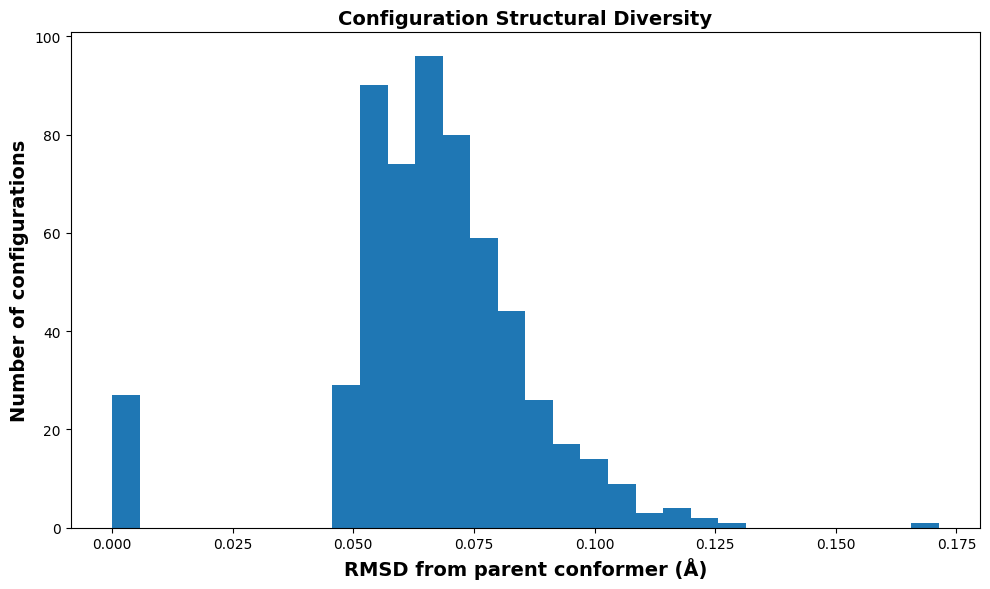

Saved: /content/drive/MyDrive/MLIP project/results/figures/rmsd_distribution.png


In [38]:
plt.figure(figsize=(10, 6))

plt.hist(
    configuration_df[
        "rmsd_from_parent_A"
    ],
    bins=30
)

plt.xlabel(
    "RMSD from parent conformer (Å)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of configurations",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Configuration Structural Diversity",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    FIGURES_DIR /
    "rmsd_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

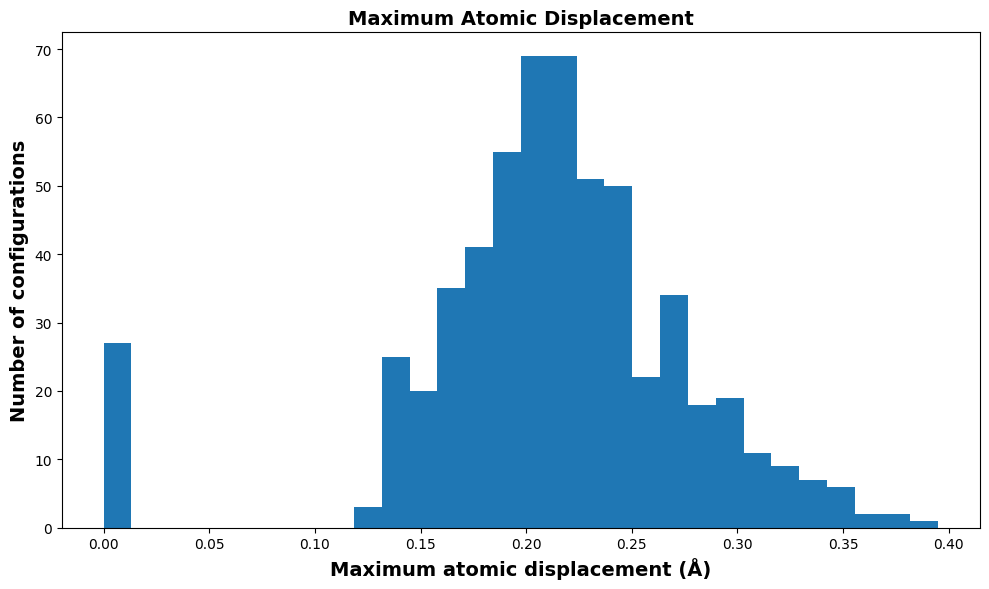

Saved: /content/drive/MyDrive/MLIP project/results/figures/displacement_distribution.png


In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    configuration_df[
        "max_atom_displacement_A"
    ],
    bins=30
)

plt.xlabel(
    "Maximum atomic displacement (Å)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of configurations",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Maximum Atomic Displacement",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

path = (
    FIGURES_DIR /
    "displacement_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

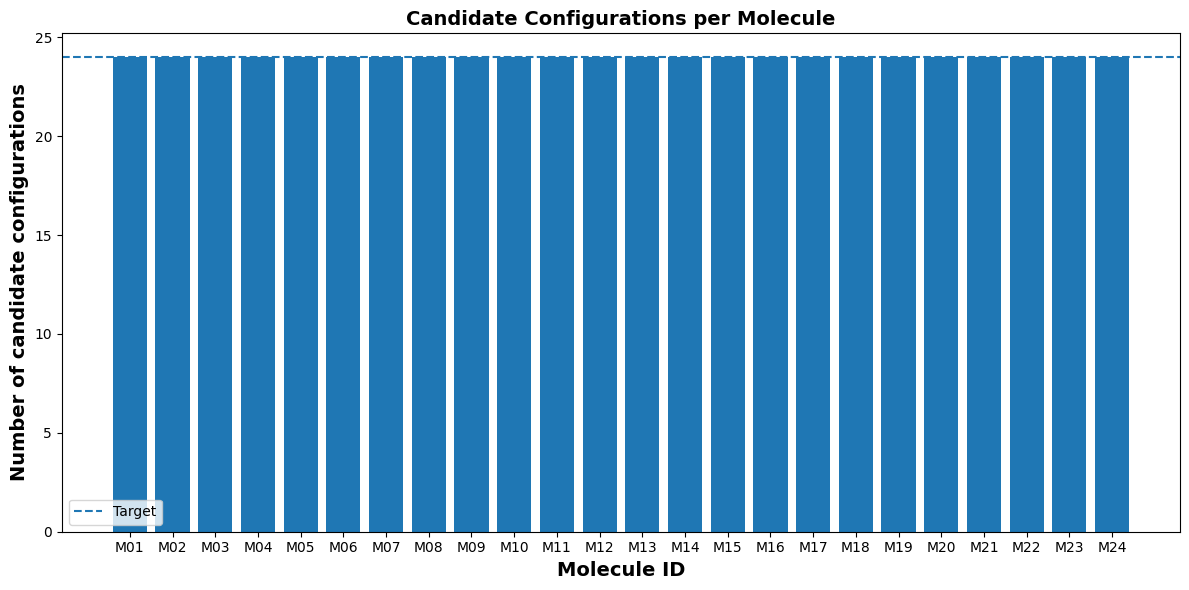

Saved: /content/drive/MyDrive/MLIP project/results/figures/configuration_count.png


In [40]:
plt.figure(figsize=(12, 6))

plt.bar(
    configuration_counts["molecule_id"],
    configuration_counts[
        "configuration_count"
    ]
)

plt.axhline(
    TARGET_CONFIGS_PER_MOLECULE,
    linestyle="--",
    linewidth=1.5,
    label="Target"
)

plt.xlabel(
    "Molecule ID",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of candidate configurations",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Candidate Configurations per Molecule",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

path = (
    FIGURES_DIR /
    "configuration_count.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [41]:
source_counts = (
    configuration_df[
        "source_type"
    ]
    .value_counts()
)

display(
    source_counts.to_frame(
        "number_of_configurations"
    )
)

,number_of_configurations
source_type,
perturbed,549
mmff_conformer,27


In [42]:
sigma_counts = (
    configuration_df[
        "perturbation_sigma_A"
    ]
    .value_counts()
    .sort_index()
)

display(
    sigma_counts.to_frame(
        "number_of_configurations"
    )
)

,number_of_configurations
perturbation_sigma_A,
0.000,27
0.050,61
0.075,303
0.100,142
0.125,43


In [43]:
final_manifest = configuration_df.merge(
    geometry_check_df,
    on="configuration_id",
    how="left"
)

final_manifest_path = (
    PROCESSED_DIR /
    "configuration_manifest.csv"
)

final_manifest.to_csv(
    final_manifest_path,
    index=False
)

print(
    "Final configuration manifest saved:"
)

print(final_manifest_path)

Final configuration manifest saved:
/content/drive/MyDrive/MLIP project/data/processed/configuration_manifest.csv


In [44]:
print("=" * 70)
print("NOTEBOOK 03 — FINAL VALIDATION")
print("=" * 70)

print(
    f"Number of molecules              : "
    f"{molecule_df['id'].nunique()}"
)

print(
    f"Number of configurations         : "
    f"{len(final_manifest)}"
)

print(
    f"Unique configuration IDs         : "
    f"{final_manifest['configuration_id'].nunique()}"
)

print(
    f"Families represented             : "
    f"{final_manifest['family'].nunique()}"
)

print(
    f"Minimum configurations/molecule  : "
    f"{configuration_counts['configuration_count'].min()}"
)

print(
    f"Maximum configurations/molecule  : "
    f"{configuration_counts['configuration_count'].max()}"
)

print(
    f"Minimum pair distance             : "
    f"{final_manifest['minimum_distance_A'].min():.3f} Å"
)

print(
    f"Maximum atom displacement         : "
    f"{final_manifest['max_atom_displacement_A'].max():.3f} Å"
)

print(
    f"Maximum RMSD from parent          : "
    f"{final_manifest['rmsd_from_parent_A'].max():.3f} Å"
)

assert molecule_df["id"].nunique() == 24

assert (
    final_manifest["configuration_id"].nunique()
    ==
    len(final_manifest)
)

assert final_manifest["family"].nunique() == 6

assert (
    final_manifest["finite_coordinates"]
    .all()
)

print("\nALL FINAL VALIDATION TESTS PASSED.")

NOTEBOOK 03 — FINAL VALIDATION
Number of molecules              : 24
Number of configurations         : 576
Unique configuration IDs         : 576
Families represented             : 6
Minimum configurations/molecule  : 24
Maximum configurations/molecule  : 24
Minimum pair distance             : 0.782 Å
Maximum atom displacement         : 0.395 Å
Maximum RMSD from parent          : 0.171 Å

ALL FINAL VALIDATION TESTS PASSED.


In [45]:
summary_path = (
    PROCESSED_DIR /
    "configuration_generation_summary.txt"
)

with open(summary_path, "w") as f:

    f.write(
        "EnergyMol-MLIP\n"
        "Notebook 03: Conformer and Configuration Generation\n"
        "\n"
    )

    f.write(
        f"Number of molecules: "
        f"{molecule_df['id'].nunique()}\n"
    )

    f.write(
        f"Number of configurations: "
        f"{len(final_manifest)}\n"
    )

    f.write(
        f"Target configurations/molecule: "
        f"{TARGET_CONFIGS_PER_MOLECULE}\n"
    )

    f.write(
        f"Perturbation sigmas (A): "
        f"{PERTURBATION_SIGMAS}\n"
    )

    f.write(
        f"Minimum RMSD threshold (A): "
        f"{MIN_CONFIG_RMSD}\n"
    )

    f.write(
        f"Maximum atom displacement (A): "
        f"{MAX_ATOM_DISPLACEMENT}\n"
    )

    f.write(
        f"Bond ratio range: "
        f"{MIN_BOND_RATIO} - "
        f"{MAX_BOND_RATIO}\n"
    )

    f.write(
        f"Minimum nonbonded vdW ratio: "
        f"{MIN_NONBONDED_VDW_RATIO}\n"
    )

print(
    "Summary saved:"
)

print(summary_path)

Summary saved:
/content/drive/MyDrive/MLIP project/data/processed/configuration_generation_summary.txt
